**Árvore de Decisão:**

In [ ]:
from sklearn.datasets import load_iris
from sklearn import tree
iris = load_iris()
print(iris['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

*Dividindo a base em treino e teste:*

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(iris.data,
  iris.target, test_size=0.25, random_state=1)

*Construindo o modelo:*

In [ ]:
modelo = tree.DecisionTreeClassifier(criterion='entropy', max_depth=3)
modelo = modelo.fit(X_train, y_train)  # treino
predictions = modelo.predict(X_test)  # previsões

In [ ]:
predictions

array([0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       2, 0, 2, 1, 0, 0, 1, 2, 1, 2, 1, 2, 2, 0, 1, 0])

In [ ]:
y_test

array([0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 2, 1, 0, 0, 1, 2, 1, 2, 1, 2, 2, 0, 1, 0])

*Avaliação:*

In [ ]:
import pandas as pd
print("\nMatriz de confusão detalhada:\n",
      pd.crosstab(y_test, predictions, rownames=['Real'],
      colnames=['Predito'], margins=True, margins_name='Todos'))


Matriz de confusão detalhada:
 Predito   0   1   2  Todos
Real                      
0        13   0   0     13
1         0  15   1     16
2         0   0   9      9
Todos    13  15  10     38


**Medidas usadas em avaliação:**

**VP**: verdadeiro positivo (Previ que iria acontecer e aconteceu)

**VN**: verdadeiro negativo (Previ que não iria acontecer e não aconteceu)

**FP**: falso positivo (Previ que iria acontecer e não aconteceu)

**FN**: falso negativo (Previ que não iria acontecer e aconteceu)

* Precisão ou precision (a precisão é intuitivamente a habilidade de não
classificar como positiva uma amostra que é negativa) = VP/(VP+FP)

* Acurácia ou accuracy = (VP + VN) / (VP+VN+FP+FN) (Tudo o que eu acertei / todos os testes)

* Cobertura ou recall (acerto com os verdadeiros positivos ou acurácia
positiva; intuitivamente a habilidade do classificador de encontrar todas
as amostras positivas) = VP/(VP+FN)

* Acerto com os verdadeiros negativos ou acurácia negativa

* Medida-F ou F1 score (média harmônica entre precisão e cobertura; é apropriada para situações de desbalanceamento entre classes)

* Média-G (média geométrica entre a acurácia positiva e a acurácia
negativa)

In [ ]:
import sklearn.metrics as metrics


Relatório sobre a qualidade:

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        13
  Versicolor       1.00      0.94      0.97        16
   Virgínica       0.90      1.00      0.95         9

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38



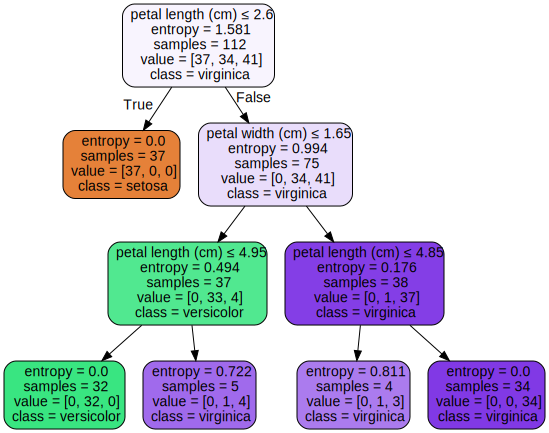

In [ ]:
import graphviz
dot_data = tree.export_graphviz(modelo, out_file=None)
graph = graphviz.Source(dot_data)
graph.render("iris")
dot_data = tree.export_graphviz(modelo, out_file=None,
  feature_names=iris.feature_names, class_names=iris.target_names,
  filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data, format="png")
graph

In [ ]:
#Exercício 1
import sklearn.metrics as metrics
ts_list = [0.10, 0.25, 0.50, 0.75, 0.90]
acc_list = []
for ts in ts_list:
  X_train, X_test, y_train, y_test = train_test_split(iris.data,
    iris.target, test_size=ts, random_state=1)
  modelo = tree.DecisionTreeClassifier(criterion='entropy', max_depth=3)
  modelo = modelo.fit(X_train, y_train)  # treino
  predictions = modelo.predict(X_test)  # previsões
  print(f"Relatório sobre a qualidade (test_size = {ts}):\n")
  x = metrics.accuracy_score(y_test, predictions)
  acc_list.append(x)
  print(metrics.classification_report(y_test, predictions, target_names = ['Setosa', 'Versicolor', 'Virginica']))
  print(x)
print(acc_list)

Relatório sobre a qualidade (test_size = 0.1):

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00         5
  Versicolor       1.00      1.00      1.00         6
   Virginica       1.00      1.00      1.00         4

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15

1.0
Relatório sobre a qualidade (test_size = 0.25):

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        13
  Versicolor       1.00      0.94      0.97        16
   Virginica       0.90      1.00      0.95         9

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38

0.9736842105263158
Relatório sobre a qualidade (test_size = 0.5):

              precision    recall  f1-score   support

      Setosa   

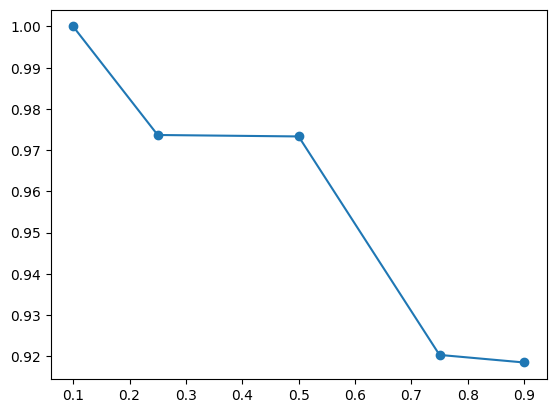

In [ ]:
#Gerar gráficos
import matplotlib.pyplot as plt
plt.plot(ts_list,acc_list, marker = 'o')
plt.show()



In [ ]:
#Exercício 2
import sklearn.metrics as metrics
ts_list = [0.10, 0.25, 0.50, 0.75, 0.90]
acc_list = []
for ts in ts_list:
  X_train, X_test, y_train, y_test = train_test_split(iris.data,
    iris.target, test_size=ts, random_state=1)
  modelo = tree.DecisionTreeClassifier(criterion='entropy', max_depth=5)
  modelo = modelo.fit(X_train, y_train)  # treino
  predictions = modelo.predict(X_test)  # previsões
  print(f"Relatório sobre a qualidade (test_size = {ts}):\n")
  x = metrics.accuracy_score(y_test, predictions)
  acc_list.append(x)
  print(metrics.classification_report(y_test, predictions, target_names = ['Setosa', 'Versicolor', 'Virginica']))
  print(x)
print(acc_list)

Relatório sobre a qualidade (test_size = 0.1):

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00         5
  Versicolor       1.00      1.00      1.00         6
   Virginica       1.00      1.00      1.00         4

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15

1.0
Relatório sobre a qualidade (test_size = 0.25):

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        13
  Versicolor       1.00      0.94      0.97        16
   Virginica       0.90      1.00      0.95         9

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38

0.9736842105263158
Relatório sobre a qualidade (test_size = 0.5):

              precision    recall  f1-score   support

      Setosa   

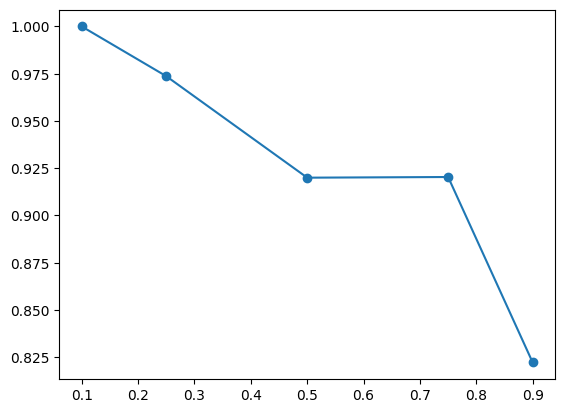

In [ ]:
#Gerar gráficos
import matplotlib.pyplot as plt
plt.plot(ts_list,acc_list, marker = 'o')
plt.show()

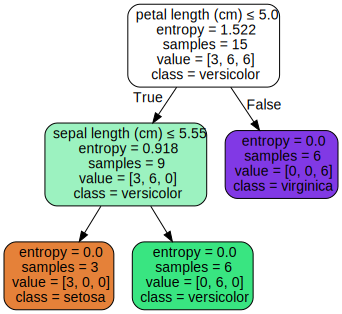

In [ ]:
import graphviz
dot_data = tree.export_graphviz(modelo, out_file=None)
graph = graphviz.Source(dot_data)
graph.render("iris")
dot_data = tree.export_graphviz(modelo, out_file=None,
  feature_names=iris.feature_names, class_names=iris.target_names,
  filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data, format="png")
graph

**Base sobre saúde pública nos EUA:**

In [ ]:
!wget https://github.com/cedmenezes/estudos/raw/main/nhanes.csv
df = pd.read_csv('nhanes.csv')

--2025-04-04 13:42:47--  https://github.com/cedmenezes/estudos/raw/main/nhanes.csv
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/cedmenezes/estudos/main/nhanes.csv [following]
--2025-04-04 13:42:48--  https://raw.githubusercontent.com/cedmenezes/estudos/main/nhanes.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 58913 (58K) [text/plain]
Saving to: ‘nhanes.csv’

nhanes.csv          100%[===================>]  57.53K  --.-KB/s    in 0.01s   

2025-04-04 13:42:48 (4.33 MB/s) - ‘nhanes.csv’ saved [58913/58913]

